Loaded 47,354 rows × 28 columns
Plotting 27 cluster features in a 7×4 grid


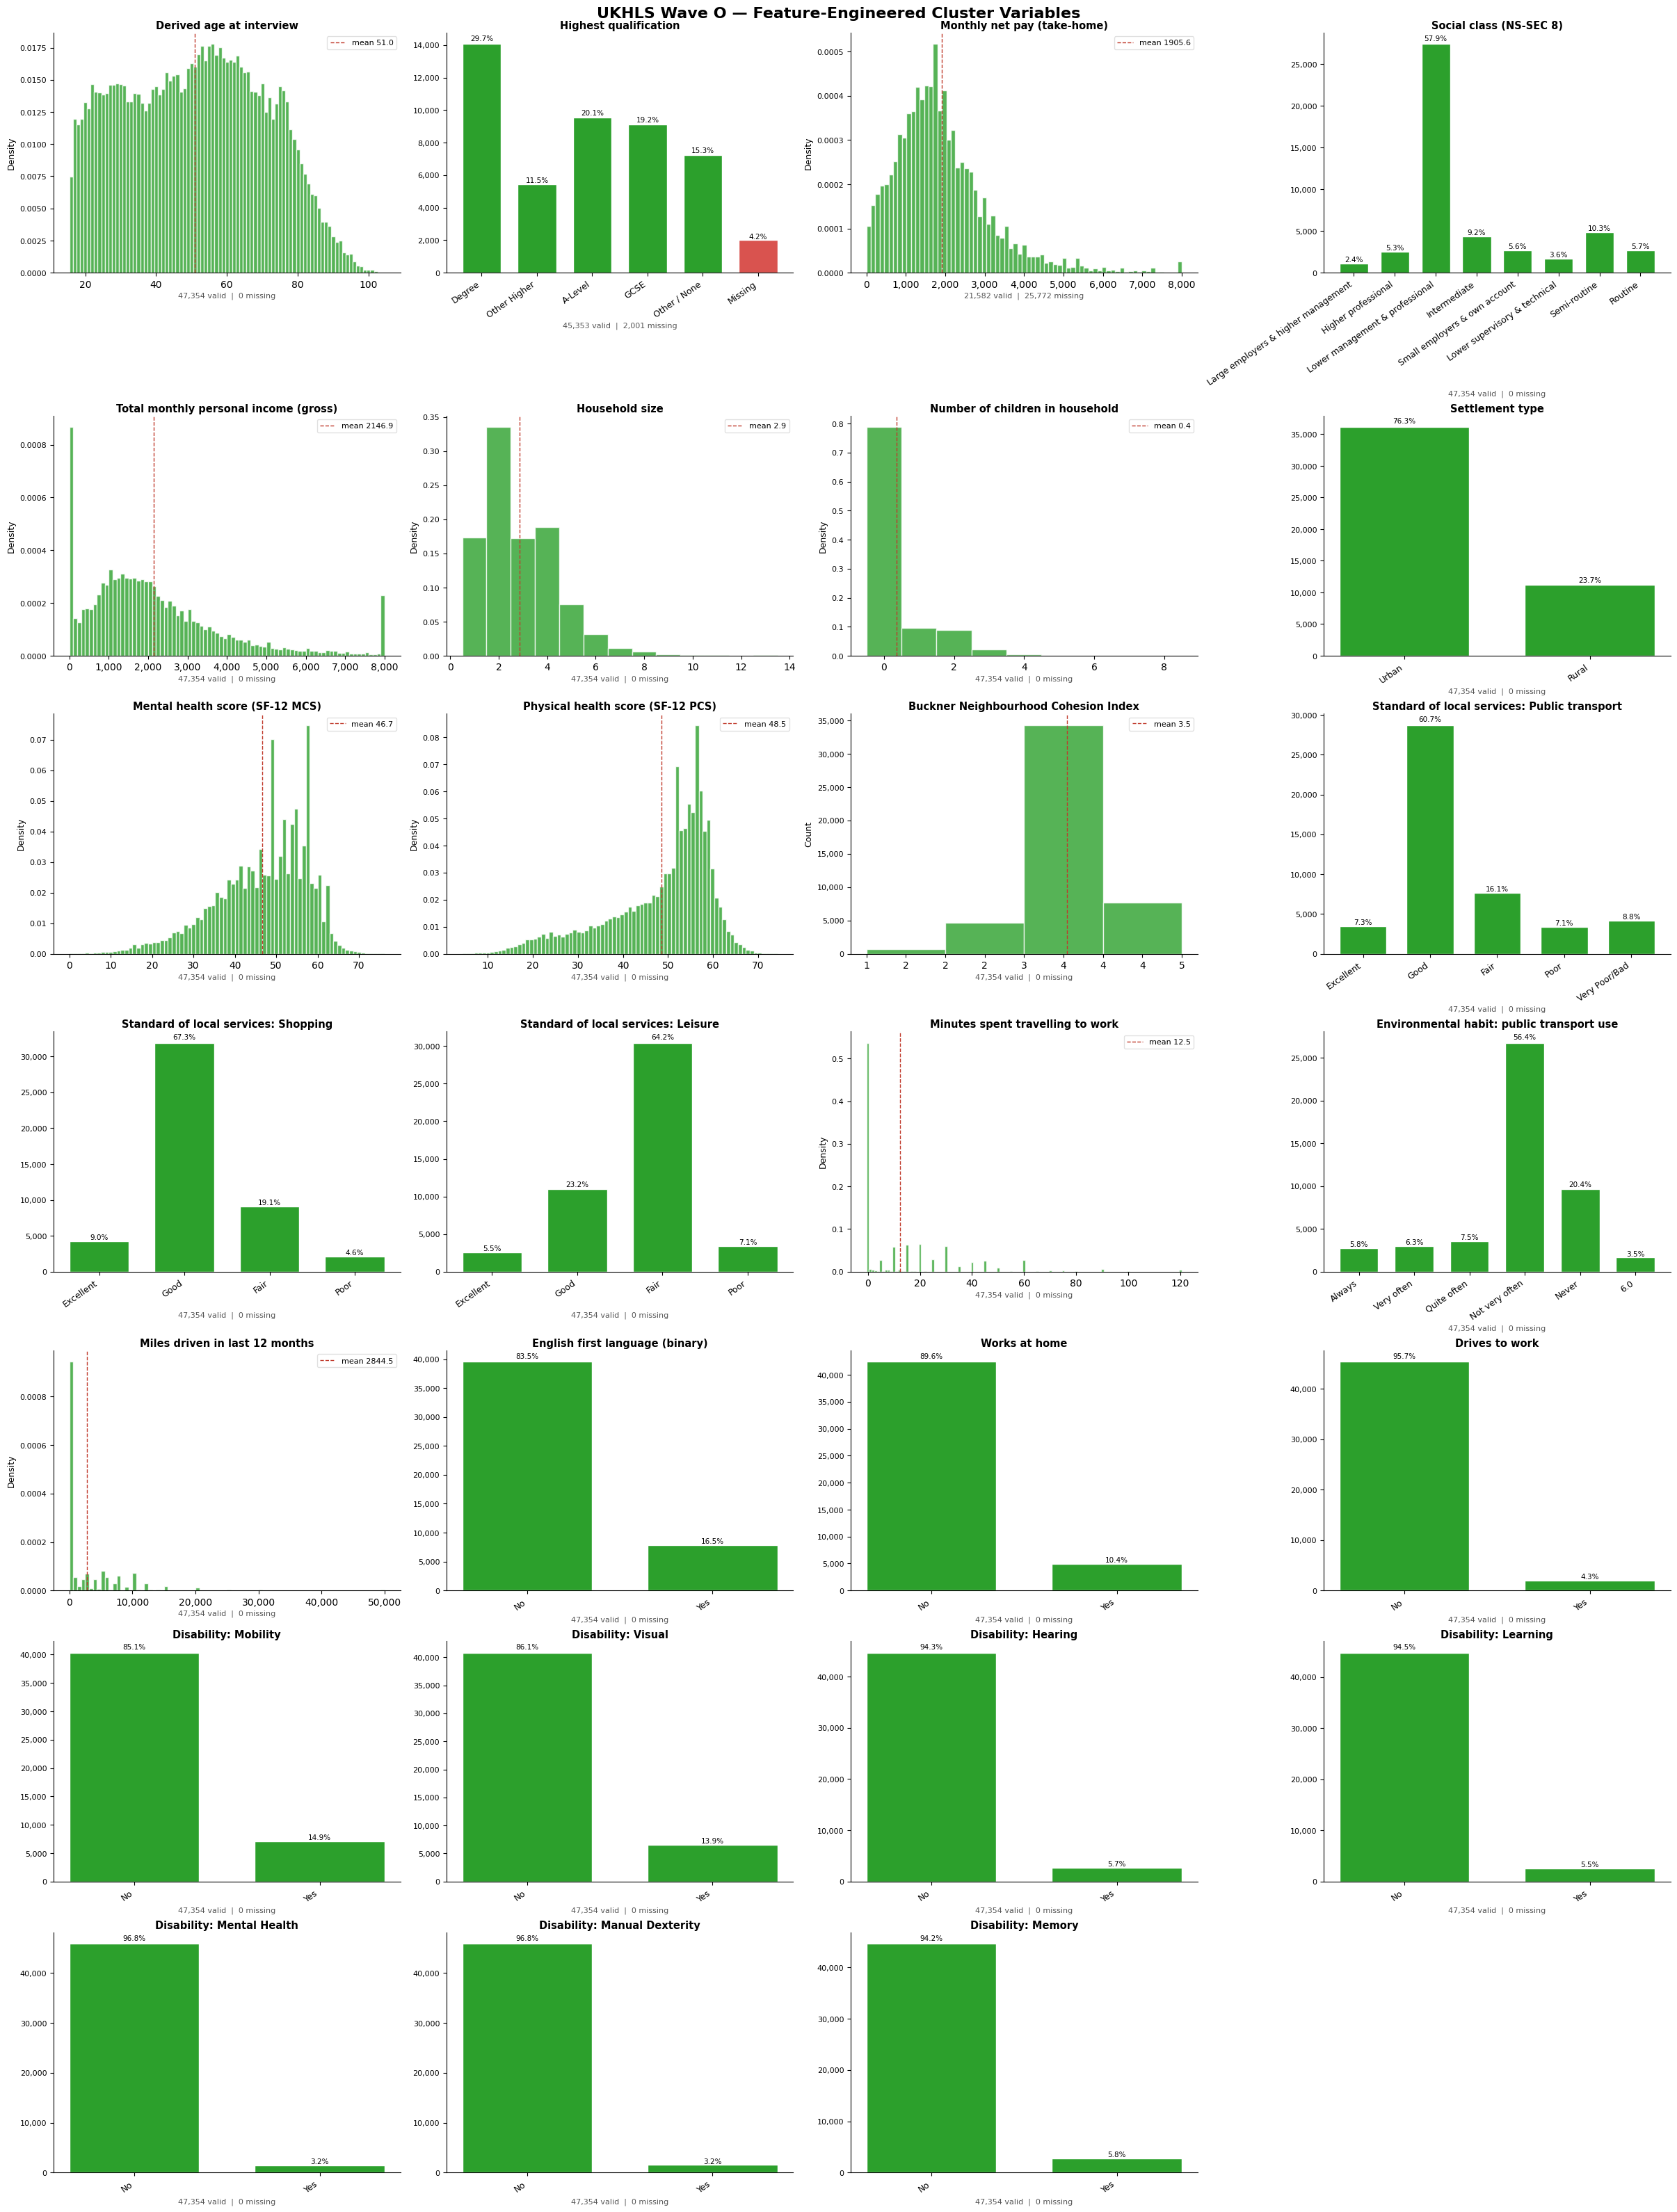

Saved to ../data/4_feature_eng_ukhls/feature_eng_distributions.png


In [9]:
# 4_visualise_feature_eng.ipynb
#
# Plots every cluster feature after feature engineering:
# recodes, floors and clips have all been applied.
# Use this to validate 4_feature_eng_ukhls.ipynb output.

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import importlib
import data_processing.ukhls_variables as _ukhls_vars
importlib.reload(_ukhls_vars)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from data_processing.ukhls_variables import (
    VARIABLES, CLUSTER_VARS, CATEGORICAL_VARS, CATEGORY_MAPS
)

# ── Config ────────────────────────────────────────────────────────────────────
WAVE          = "o"
PICKLE_PATH   = "../data/4_feature_eng_ukhls/o_indresp_feature_eng.pkl"
COLS_PER_ROW  = 4
BAR_COLOR     = "#2ca02c"
HIST_COLOR    = "#2ca02c"
MISSING_COLOR = "#d9534f"

# ── Load ─────────────────────────────────────────────────────────────────────
if not os.path.exists(PICKLE_PATH):
    raise FileNotFoundError(f"{PICKLE_PATH} not found — run 4_feature_eng_ukhls.ipynb first.")

df = pd.read_pickle(PICKLE_PATH)
print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")

# ── Build plot specs (cluster vars only) ──────────────────────────────────────
plot_specs = []
for base_code in CLUSTER_VARS:
    col = f"{WAVE}_{base_code}"
    if col not in df.columns:
        continue
    var_def = VARIABLES.get(base_code, {})
    plot_specs.append(dict(
        col        = col,
        label      = var_def.get("label", base_code),
        is_cat     = var_def.get("categorical", False),
        categories = var_def.get("categories"),
        bin_width  = var_def.get("bin_width"),  # fixed histogram bin width or None
    ))

n_plots = len(plot_specs)
n_cols  = COLS_PER_ROW
n_rows  = (n_plots + n_cols - 1) // n_cols
print(f"Plotting {n_plots} cluster features in a {n_rows}×{n_cols} grid")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4.5*n_rows), constrained_layout=True)
axes_flat = axes.flatten()

for idx, spec in enumerate(plot_specs):
    ax   = axes_flat[idx]
    col  = spec["col"]
    data = df[col]

    n_valid   = data.notna().sum()
    n_missing = data.isna().sum()
    subtitle  = f"{n_valid:,} valid  |  {n_missing:,} missing"

    if (spec["is_cat"] and not spec["bin_width"]) or (data.nunique(dropna=True) <= 12 and spec["categories"] is not None):
        cat_map   = spec["categories"] or {}
        raw       = data.value_counts(dropna=False).sort_index(na_position="last")
        labels_x, counts_y, colors = [], [], []
        for rv, cnt in raw.items():
            if pd.isna(rv):
                labels_x.append("Missing"); colors.append(MISSING_COLOR)
            else:
                labels_x.append(cat_map.get(float(rv), str(rv))); colors.append(BAR_COLOR)
            counts_y.append(cnt)
        bars  = ax.bar(range(len(labels_x)), counts_y, color=colors, edgecolor="white", width=0.7)
        total = sum(counts_y)
        ax.set_xticks(range(len(labels_x)))
        ax.set_xticklabels(labels_x, rotation=35, ha="right", fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        for bar, cnt in zip(bars, counts_y):
            pct = 100 * cnt / total if total else 0
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                    f"{pct:.1f}%", ha="center", va="bottom", fontsize=7.5)
    else:
        vals = pd.to_numeric(data, errors="coerce").dropna()
        if len(vals) == 0:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        else:
            val_min, val_max = vals.min(), vals.max()
            bin_width = spec["bin_width"]
            if bin_width is not None:
                bins = np.arange(val_min, val_max + bin_width, bin_width)
            elif ((vals % 1) == 0).all() and val_max - val_min <= 120:
                bins = np.arange(val_min-0.5, val_max+1.5, 1)
            else:
                bins = min(80, max(20, len(vals)//300))
            use_density = bin_width is None
            ax.hist(vals, bins=bins, color=HIST_COLOR, edgecolor="white", density=use_density, alpha=0.8)
            ax.axvline(vals.mean(), color="#c0392b", linestyle="--", linewidth=1,
                       label=f"mean {vals.mean():.1f}")
            ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
            if not use_density:
                ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
            ax.legend(fontsize=8, framealpha=0.6)
        ax.set_ylabel("Density" if use_density else "Count", fontsize=9)

    ax.set_title(spec["label"], fontsize=10.5, fontweight="bold", pad=4)
    ax.set_xlabel(subtitle, fontsize=8, labelpad=3, color="#555")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

for unused in axes_flat[n_plots:]:
    unused.set_visible(False)

fig.suptitle(
    f"UKHLS Wave {WAVE.upper()} — Feature-Engineered Cluster Variables",
    fontsize=16, fontweight="bold", y=1.005,
)
plt.savefig("../data/4_feature_eng_ukhls/feature_eng_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to ../data/4_feature_eng_ukhls/feature_eng_distributions.png")
